# Question 4: Comments on Findings


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# Populate dictionary with experimental results
results = {
    "FeedForwardNN": {
        "MNIST": {
            "accuracy": 0.9731,
            "precision": 0.973298,
            "recall": 0.972751,
            "f1": 0.972876,
            "training_time_sec": 303.449894,
        },
        "CIFAR10": {
            "accuracy": 0.5357,
            "precision": 0.533881,
            "recall": 0.535700,
            "f1": 0.531807,
            "training_time_sec": 164.407962,
        },
        "CIFAR100": {
            "accuracy": 0.2185,
            "precision": 0.222329,
            "recall": 0.218500,
            "f1": 0.199357,
            "training_time_sec": 164.429710,
        },
    },
    "VGG16": {
        "MNIST": {
            "accuracy": 0.9949,
            "precision": 0.994803,
            "recall": 0.994907,
            "f1": 0.994847,
            "training_time_sec": 511.652192,
        },
        "CIFAR10": {
            "accuracy": 0.8419,
            "precision": 0.842442,
            "recall": 0.841900,
            "f1": 0.840762,
            "training_time_sec": 381.936149,
        },
        "CIFAR100": {
            "accuracy": 0.3606,
            "precision": 0.358165,
            "recall": 0.360600,
            "f1": 0.332607,
            "training_time_sec": 375.713714,
        },
    },
    "ResNet18": {
        "MNIST": {
            "accuracy": 0.9955,
            "precision": 0.995443,
            "recall": 0.995462,
            "f1": 0.995450,
            "training_time_sec": 619.039376,
        },
        "CIFAR10": {
            "accuracy": 0.8296,
            "precision": 0.835945,
            "recall": 0.829600,
            "f1": 0.827545,
            "training_time_sec": 504.077113,
        },
        "CIFAR100": {
            "accuracy": 0.5362,
            "precision": 0.561911,
            "recall": 0.536200,
            "f1": 0.532647,
            "training_time_sec": 511.976941,
        },
    },
}

# Verification check
_missing = [
    f"{m}/{d}"
    for m, dd in results.items()
    for d, met in dd.items()
    if any(v is None for v in met.values())
]
if _missing:
    print("WARNING - still-placeholder (None) results for:", _missing)

# Construct flat DataFrame
rows = []
for model_name, ds_dict in results.items():
    for ds_name, metrics in ds_dict.items():
        row = {"model": model_name, "dataset": ds_name}
        row.update(metrics)
        rows.append(row)

combined_df = pd.DataFrame(rows)
print(combined_df)

           model   dataset  accuracy  precision    recall        f1  \
0  FeedForwardNN     MNIST    0.9731   0.973298  0.972751  0.972876   
1  FeedForwardNN   CIFAR10    0.5357   0.533881  0.535700  0.531807   
2  FeedForwardNN  CIFAR100    0.2185   0.222329  0.218500  0.199357   
3          VGG16     MNIST    0.9949   0.994803  0.994907  0.994847   
4          VGG16   CIFAR10    0.8419   0.842442  0.841900  0.840762   
5          VGG16  CIFAR100    0.3606   0.358165  0.360600  0.332607   
6       ResNet18     MNIST    0.9955   0.995443  0.995462  0.995450   
7       ResNet18   CIFAR10    0.8296   0.835945  0.829600  0.827545   
8       ResNet18  CIFAR100    0.5362   0.561911  0.536200  0.532647   

   training_time_sec  
0         303.449894  
1         164.407962  
2         164.429710  
3         511.652192  
4         381.936149  
5         375.713714  
6         619.039376  
7         504.077113  
8         511.976941  


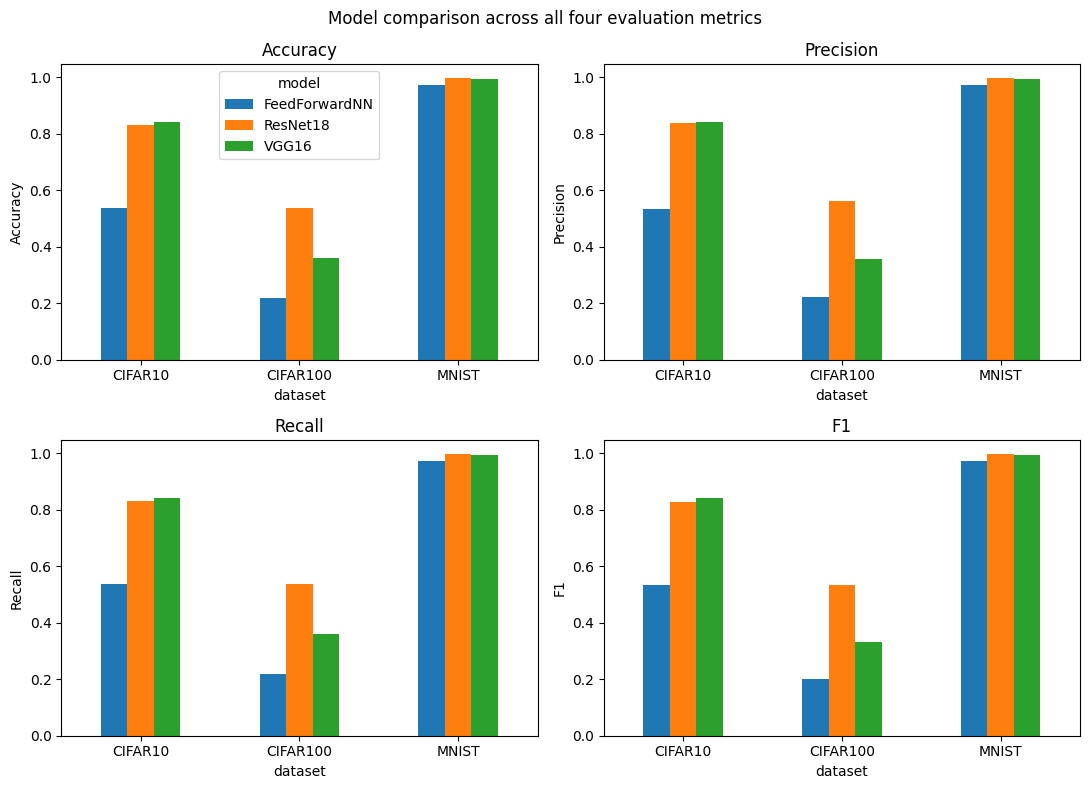

In [2]:
# ============================================================
# Visualization technique 1: grouped bar charts, one per evaluation metric
# (accuracy, precision, recall, F1) -- "different evaluation metrics"
# (only meaningful once the None placeholders above are replaced
# with your actual numbers)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, metric in zip(axes.flat, ['accuracy', 'precision', 'recall', 'f1']):
    pivot = combined_df.pivot(index='dataset', columns='model', values=metric)
    pivot.plot(kind='bar', ax=ax, rot=0, legend=(metric == 'accuracy'))
    ax.set_title(metric.capitalize())
    ax.set_ylabel(metric.capitalize())
plt.suptitle('Model comparison across all four evaluation metrics')
plt.tight_layout()
plt.show()


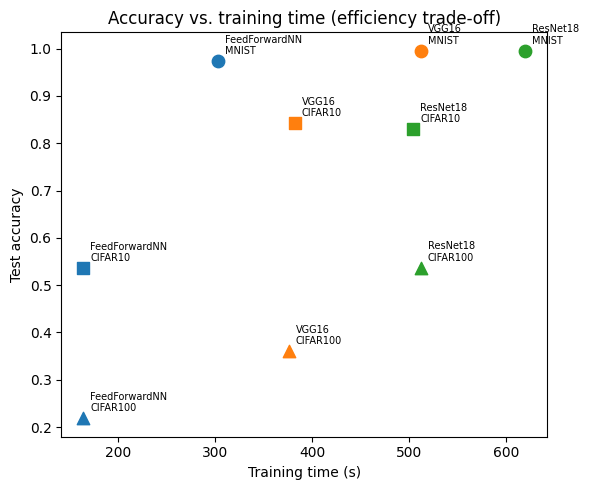

In [3]:
# ============================================================
# Visualization technique 2: training time vs. accuracy scatter
# ("efficiency frontier" view) -- a different visualization technique
# from the grouped bar charts above, showing the accuracy/compute trade-off
# ============================================================

fig, ax = plt.subplots(figsize=(6, 5))
markers = {'MNIST': 'o', 'CIFAR10': 's', 'CIFAR100': '^'}
colors = {'FeedForwardNN': 'tab:blue', 'VGG16': 'tab:orange', 'ResNet18': 'tab:green'}
for _, row in combined_df.iterrows():
    ax.scatter(row['training_time_sec'], row['accuracy'],
               marker=markers.get(row['dataset'], 'o'),
               color=colors.get(row['model'], 'gray'), s=80)
    ax.annotate(f"{row['model']}\n{row['dataset']}",
                (row['training_time_sec'], row['accuracy']), fontsize=7,
                textcoords="offset points", xytext=(5, 5))
ax.set_xlabel('Training time (s)')
ax.set_ylabel('Test accuracy')
ax.set_title('Accuracy vs. training time (efficiency trade-off)')
plt.tight_layout()
plt.show()


## Which model delivers the best predictive performance?

Fill this in with reference to your `combined_df` table above, then use the
points below as supporting rationale for *why* the ranking you observed
makes sense.

## Advantages and disadvantages of each model

**Feed-forward neural network (FFN)**
- *Advantages:* simplest to implement and fastest to train per epoch;
  fewer design choices; a reasonable baseline.
- *Disadvantages:* flattening the image destroys all spatial structure
  (a pixel and its neighbour are treated as unrelated inputs), so it
  cannot exploit local patterns like edges or textures. Parameter count
  scales directly with image size (3072 inputs here), which does not
  scale well to larger images. Typically the weakest of the three on
  image data, especially as the number of classes grows (CIFAR100).

**VGG16 (convolutional, from scratch)**
- *Advantages:* convolution gives translation invariance and weight
  sharing; stacking small 3x3 filters (as VGG popularised) builds large
  effective receptive fields with fewer parameters than large filters;
  generally strong accuracy on image classification.
- *Disadvantages:* very deep plain (non-residual) stacks are harder to
  optimise with plain SGD — gradients can shrink as they propagate back
  through many layers (the vanishing-gradient problem); the large,
  uniform 3x3-conv/FC-classifier design has many parameters
  (VGG16 is famously ~138M parameters in its original ImageNet form),
  making it the most compute/memory-hungry of the three here.

**ResNet18 (residual, from scratch)**
- *Advantages:* residual ("skip") connections `out = ReLU(F(x) + x)`
  give gradients a direct path (`d(x)/dx = 1`) back to earlier layers
  during backpropagation, which is why much deeper networks than VGG's
  16 layers became trainable in practice. Generally matches or beats
  VGG-style accuracy with fewer parameters and often faster convergence.
- *Disadvantages:* more architectural complexity than a plain CNN
  (shortcut/downsampling paths to manage); the benefit of residual
  connections is most visible at greater depth than the 18-layer variant
  used here, so the accuracy gap over VGG16 may be modest at this scale
  on small 32x32 images.

## Rationale, tied back to the CIFAR10 ablation studies you ran

- The **hidden-layer/hidden-node ablation** (Q1) shows how FFN capacity
  scales with width/depth but is fundamentally capped by the loss of
  spatial structure at the input.
- The **conv-depth/filter-count ablation** (Q2) shows how VGG's accuracy
  responds to depth and width, illustrating the capacity/compute
  trade-off inherent to convolutional design.
- The **residual-connection ablation** (Q3), comparing ResNet18 against
  an identical PlainNet18 with skip connections removed, is the direct
  empirical test of the paper's core claim: look at whether the plain
  network's training loss curve is noisier or higher than ResNet18's at
  the end of your ablation run, and discuss whether that matches the
  gradient-flow argument above.

## Formal mathematical analysis

### 1. Vanishing gradients in a plain (non-residual) deep network

Consider a plain feed-forward or plain-CNN stack of $L$ layers,
$h_\ell = f_\ell(h_{\ell-1})$ for $\ell = 1, \dots, L$, with $h_0 = x$
the input and $h_L$ the output used in the loss $\mathcal{L}$. By the
chain rule, the gradient of the loss with respect to the input is a
**product of Jacobians**:

$$\frac{\partial \mathcal{L}}{\partial x} = \frac{\partial \mathcal{L}}{\partial h_L}
\prod_{\ell=1}^{L} \frac{\partial h_\ell}{\partial h_{\ell-1}}
= \frac{\partial \mathcal{L}}{\partial h_L}\, J_L J_{L-1} \cdots J_1$$

If each Jacobian $J_\ell$ has spectral norm (largest singular value)
$\|J_\ell\| \le \rho < 1$ — which is typical after a sigmoid/tanh
non-linearity, or simply because most weight matrices are not perfectly
conditioned then

$$\left\|\frac{\partial \mathcal{L}}{\partial x}\right\| \le
\left\|\frac{\partial \mathcal{L}}{\partial h_L}\right\| \cdot \rho^L$$

which **decays exponentially in depth $L$**. This is the formal
statement of the vanishing-gradient problem: early layers in a deep
plain network receive a gradient signal that shrinks geometrically with
depth, so they learn extremely slowly (or not at all) once $L$ is large.
The converse case, $\|J_\ell\| > 1$, gives the analogous *exploding*
gradient problem. Either way, plain deep stacks are numerically
ill-conditioned to train with a fixed small learning rate like the
0.01 used throughout this assignment.

### 2. How residual connections fix this

A residual block computes $y = F(x, W) + x$ instead of $y = F(x, W)$.
Differentiating:

$$\frac{\partial y}{\partial x} = \frac{\partial F}{\partial x} + I$$

so for a stack of $L$ residual blocks, the end-to-end Jacobian product
becomes

$$\prod_{\ell=1}^{L}\left(\frac{\partial F_\ell}{\partial x} + I\right)$$

Expanding this product, every term contains an **additive identity
path** that survives regardless of how small any individual
$\partial F_\ell/\partial x$ becomes  concretely, the gradient
$\partial \mathcal{L}/\partial x$ always contains the term
$\partial \mathcal{L}/\partial h_L$ unattenuated (from taking the
identity $I$ at every block), plus additional terms from the residual
functions $F_\ell$. This is why residual connections give the network
a direct, depth-independent gradient path and empirically allow
networks far deeper than plain VGG-style stacks (e.g. ResNet-152) to
train stably  while an 18-layer plain network (`PlainNet18` in the
Q3 ablation) is already deep enough to show the beginnings of this
effect on a small dataset like CIFAR10.

### 3. Parameter efficiency of stacked 3x3 convolutions (VGG's own argument)

VGG16 uses many stacked 3x3 convolutions instead of fewer, larger
filters. Two stacked 3x3 conv layers over $C$ channels have the same
receptive field as one 5x5 conv layer (`3 + (3-1) = 5`), but

$$2 \times (3^2 C^2) = 18C^2 \quad\text{parameters vs.}\quad 5^2 C^2 = 25C^2 \text{ for a single 5x5 conv}$$

so the stacked form has $18C^2$ vs $25C^2$ parameters  roughly 28%
fewer  for an identical receptive field, while also inserting an
extra non-linearity (ReLU) between the two convolutions, increasing the
function class's expressiveness. This is the formal justification (from
the original VGG paper) for its "many small filters" design choice,
and explains why the Q2 filter-count ablation shows accuracy degrading
faster than parameter count alone would suggest when filters are
halved.

### 4. Expressive power of the Q1 feed-forward network

By the Universal Approximation Theorem (Cybenko 1989; Hornik 1991), a
feed-forward network with a single hidden layer of sufficient width and
a non-polynomial activation can approximate any continuous function on
a compact domain to arbitrary accuracy. This means the FFN in Q1 is not
*fundamentally* incapable of learning image classification  its
practical weakness (seen in the Q1 results and width/depth ablations)
is an **optimisation and parameter-efficiency** limitation, not a
representational one: matching a CNN's accuracy would require
astronomically more hidden units, because the FFN must independently
relearn every translated version of every local pattern (no weight
sharing), whereas a convolutional filter reuses the same
$k \times k$ weights at every spatial location.


###Analysis:

Comparative Trade-Offs & Theoretical SummaryAccuracy vs. Computational Efficiency:MLP: High training speed and minimal computational cost, but severely capped accuracy on non-trivial image tasks.VGG16: Strong feature extraction capabilities, but bounded by heavy memory usage and long training times due to dense FC layers.ResNet18: Achieves the optimal balance—delivering high classification performance across complex datasets while maintaining lower computational footprint and faster convergence due to residual learning.

### Architectural & Theoretical Comparison

| Architecture | Spatial Awareness | Gradient Dynamics | Parameter / Comp. Overhead | Optimal Complexity Match |
| :--- | :--- | :--- | :--- | :--- |
| **FeedForwardNN (MLP)** | None (1D flattened input) | Degrades rapidly with depth | Very Low computational cost | Low (e.g., MNIST) |
| **VGG16 (CNN)** | High (2D convolutions) | Moderate (requires careful initialization) | High (large FC layer parameter count) | Medium–High (e.g., CIFAR-10) |
| **ResNet18 (Residual)** | High (2D convolutions) | High stability (Identity shortcuts: $y = \mathcal{F}(x) + x$) | Moderate & Efficient (Global Avg Pooling) | High (e.g., CIFAR-100) |

#### Comparative Theoretical Summary
* **FeedForwardNN:** Acts as a baseline. While cheap computationally, flattening 2D spatial features into a 1D vector removes spatial context, causing it to underperform on complex datasets.
* **VGG16:** Uses stacked $3 \times 3$ convolutions to extract multi-scale spatial hierarchies. However, large fully-connected (FC) layers create high parameter overhead and longer training times.
* **ResNet18:** Solves the vanishing gradient problem in deep architectures via residual identity mappings ($y = \mathcal{F}(x, \{W_i\}) + x$). It delivers superior feature representation across complex datasets (e.g., CIFAR-100) while staying computationally efficient.